# Multi-Branch Retail Demand Intelligence & Continuous Improvement

**Independent Kaggle Competition Project — CRISP-DM**  
**Author:** Freska Prisia Putri

This notebook translates multi-source grocery retail data into recurring performance reporting,
store and product-family diagnostics, a leakage-safe 16-day demand forecast, and an actionable
continuous-improvement backlog.

**Data source:** [Store Sales — Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting/overview)

> The competition files remain governed by Kaggle's competition rules. Raw CSV files are not
> redistributed by this repository; generated aggregates and analytical evidence are versioned.

## 1. Business understanding

The operating decision is not simply *how much will sell?* The analysis must also explain where
demand is changing, which store–family combinations need review, how reliable the forecast is,
and how analytical findings should become repeatable system and process improvements.

Business questions:

1. How is demand trending by month, store, and product family?
2. Which stores and families are growing or declining on an aligned-period basis?
3. Where is the forecast materially over- or under-estimating demand?
4. What actions, owners, monitoring cadence, and acceptance criteria should follow?

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.figsize": (11, 5), "axes.titlesize": 13, "axes.labelsize": 10})

with open(ROOT / "validation" / "source_profile.json", encoding="utf-8") as f:
    profile = json.load(f)
with open(ROOT / "validation" / "model_summary.json", encoding="utf-8") as f:
    model_summary = json.load(f)

monthly = pd.read_csv(ROOT / "data" / "reporting" / "monthly_report.csv", parse_dates=["month_start"])
branches = pd.read_csv(ROOT / "data" / "reporting" / "branch_scorecard.csv")
families = pd.read_csv(ROOT / "data" / "reporting" / "family_scorecard.csv")
forecast = pd.read_csv(ROOT / "data" / "processed" / "forecast_validation.csv", parse_dates=["date"])
forecast_store = pd.read_csv(ROOT / "data" / "reporting" / "forecast_by_store.csv")
actions = pd.read_csv(ROOT / "data" / "reporting" / "action_register.csv")

print(f"Project root: {ROOT}")
print(f"Validation rows loaded: {len(forecast):,}")

Project root: C:\Users\Lenovo\OneDrive\Documents\PORTFOLIO\retail-demand-intelligence
Validation rows loaded: 28,512


## 2. Data understanding

In [2]:
quality_summary = pd.DataFrame({
    "Check": [
        "Training rows", "Training date range", "Stores", "Product families",
        "Duplicate training IDs", "Negative sales", "Oil price nulls",
        "Holiday dates with multiple records", "Test grid rows"
    ],
    "Result": [
        f"{profile['files']['train.csv']['rows']:,}",
        f"{profile['files']['train.csv']['date_min']} to {profile['files']['train.csv']['date_max']}",
        profile['files']['stores.csv']['rows'], profile['files']['train.csv']['distinct_families'],
        profile['files']['train.csv']['duplicate_ids'], profile['files']['train.csv']['negative_sales'],
        profile['files']['oil.csv']['nulls']['dcoilwtico'], profile['integrity']['holiday_dates_with_multiple_records'],
        profile['files']['test.csv']['rows'],
    ],
    "Decision": [
        "Use chunked profiling and aggregate analytical tables",
        "Use time-based validation; never random split",
        "Store dimension", "Family dimension", "Pass", "Pass",
        "Impute or carry forward only in models that use oil",
        "Aggregate holiday attributes before joining to prevent row multiplication",
        "Complete 16-day store-family forecast horizon",
    ],
})
quality_summary

,Check,Result,Decision
0,Training rows,"3,000,888",Use chunked profiling and aggregate analytical...
1,Training date range,2013-01-01 to 2017-08-15,Use time-based validation; never random split
2,Stores,54,Store dimension
3,Product families,33,Family dimension
4,Duplicate training IDs,0,Pass
5,Negative sales,0,Pass
6,Oil price nulls,43,Impute or carry forward only in models that us...
7,Holiday dates with multiple records,31,Aggregate holiday attributes before joining to...
8,Test grid rows,28512,Complete 16-day store-family forecast horizon


### Trust boundaries

- Sales are non-negative, but zero sales are legitimate and frequent; they are not treated as
  missing values.
- Promotion counts are observed attributes, not causal treatment estimates.
- Four December 25 dates are absent from the training calendar; no synthetic sales rows are added.
- August 2017 is partial through 15 August, so year-over-year reporting uses aligned dates.

## 3. Data preparation

In [3]:
monthly["year"] = monthly["month_start"].dt.year
monthly["month_label"] = monthly["month_start"].dt.strftime("%Y-%m")
monthly_complete = monthly.loc[monthly["is_complete_month"]].copy()

print("Prepared analytical grains")
display(pd.DataFrame({
    "Dataset": ["monthly_store_family", "daily_store_performance", "forecast_validation"],
    "Grain": ["month × store × family", "date × store", "date × store × family"],
    "Primary use": ["BI slicing and trend analysis", "traffic and store monitoring", "forecast QA"],
}))

Prepared analytical grains


,Dataset,Grain,Primary use
0,monthly_store_family,month × store × family,BI slicing and trend analysis
1,daily_store_performance,date × store,traffic and store monitoring
2,forecast_validation,date × store × family,forecast QA


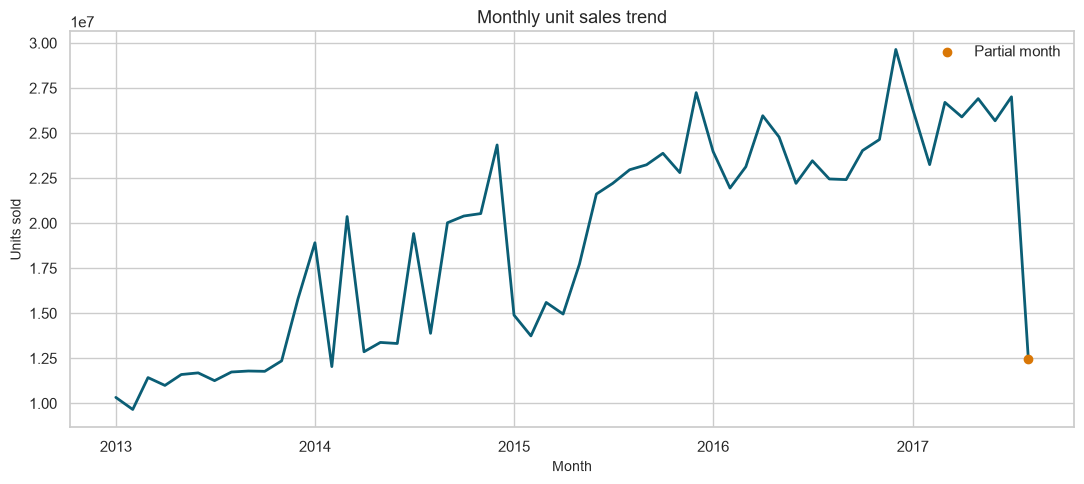

In [4]:
fig, ax = plt.subplots()
ax.plot(monthly["month_start"], monthly["unit_sales"], color="#0B5E75", linewidth=2)
ax.scatter(monthly.loc[~monthly["is_complete_month"], "month_start"],
           monthly.loc[~monthly["is_complete_month"], "unit_sales"],
           color="#D97706", label="Partial month", zorder=3)
ax.set(title="Monthly unit sales trend", xlabel="Month", ylabel="Units sold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

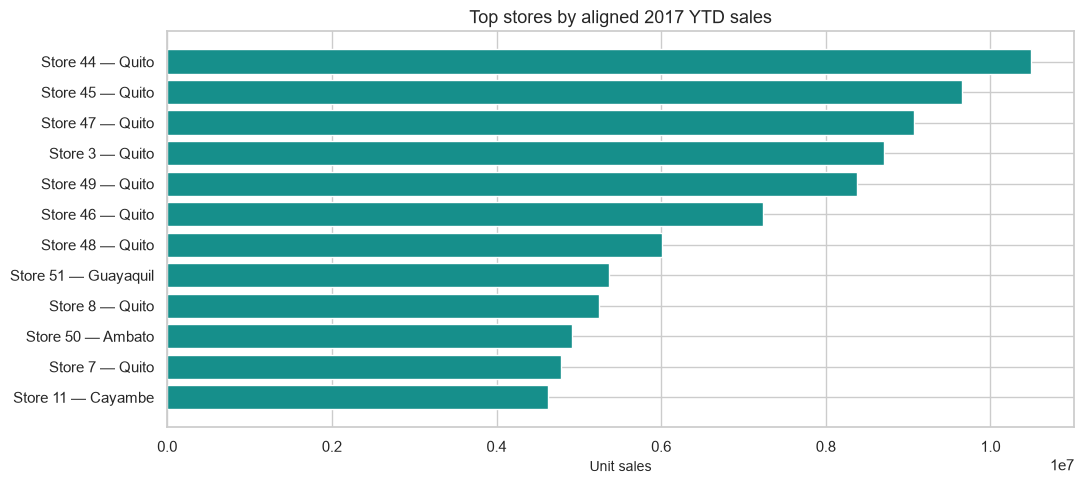

In [5]:
top_branches = branches.nlargest(12, "current_ytd_sales").sort_values("current_ytd_sales")
fig, ax = plt.subplots()
labels = [f"Store {s} — {c}" for s, c in zip(top_branches.store_nbr, top_branches.city)]
ax.barh(labels, top_branches["current_ytd_sales"], color="#168F8B")
ax.set(title="Top stores by aligned 2017 YTD sales", xlabel="Unit sales", ylabel="")
plt.tight_layout()
plt.show()

## 4. Modeling

The deployed baseline is a recursive seasonal median that uses only information available before
each forecasted date. It uses recent weekly lags at the store–family level and recursively feeds
predictions into later horizon days. The validation window mirrors the test horizon: 16 consecutive
days.

This deliberately transparent baseline establishes a reproducible benchmark before more complex
promotion-aware models such as LightGBM are considered.

In [6]:
actual = forecast["actual_sales"].clip(lower=0)
pred = forecast["forecast_sales"].clip(lower=0)
rmsle = np.sqrt(np.mean((np.log1p(pred) - np.log1p(actual)) ** 2))
bias = (pred.sum() - actual.sum()) / actual.sum()
wape = (pred - actual).abs().sum() / actual.sum()

metric_check = pd.Series({
    "Validation RMSLE": rmsle,
    "Forecast bias": bias,
    "WAPE": wape,
    "Forecast accuracy (1-WAPE)": max(0, 1 - wape),
    "Validation rows": len(forecast),
})
metric_check.to_frame("Value")

,Value
Validation RMSLE,0.551036
Forecast bias,-0.015035
WAPE,0.171801
Forecast accuracy (1-WAPE),0.828199
Validation rows,28512.000000


## 5. Evaluation

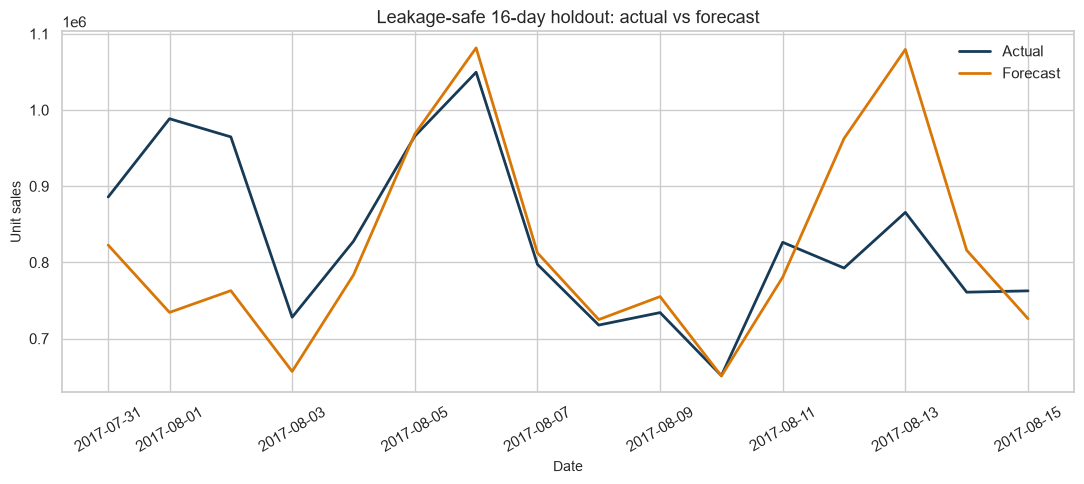

In [7]:
daily_forecast = forecast.groupby("date", as_index=False).agg(
    actual_sales=("actual_sales", "sum"), forecast_sales=("forecast_sales", "sum")
)

fig, ax = plt.subplots()
ax.plot(daily_forecast["date"], daily_forecast["actual_sales"], label="Actual", color="#173B57", linewidth=2)
ax.plot(daily_forecast["date"], daily_forecast["forecast_sales"], label="Forecast", color="#D97706", linewidth=2)
ax.set(title="Leakage-safe 16-day holdout: actual vs forecast", xlabel="Date", ylabel="Unit sales")
ax.legend(frameon=False)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

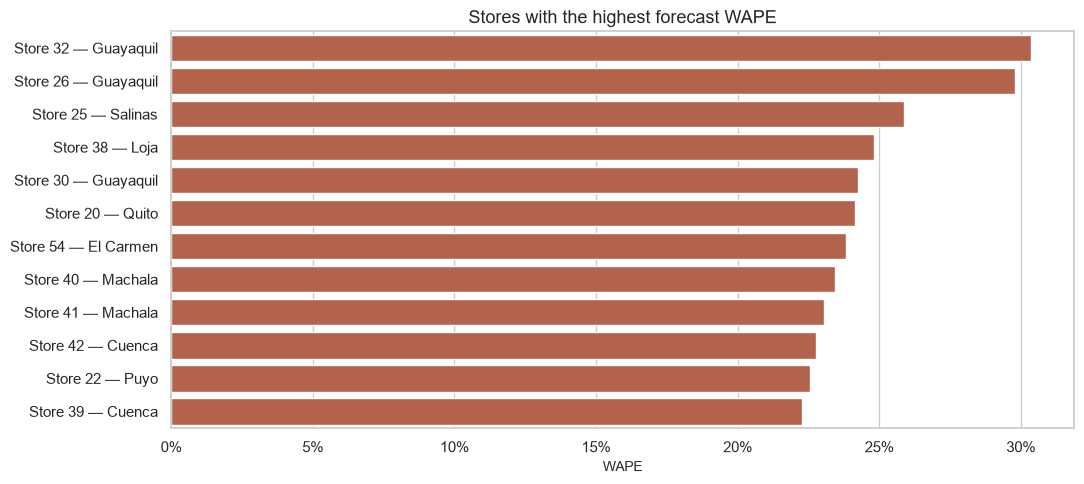

In [8]:
risk = forecast_store.sort_values("wape", ascending=False).head(12).copy()
risk["label"] = [f"Store {s} — {c}" for s, c in zip(risk.store_nbr, risk.city)]

fig, ax = plt.subplots()
sns.barplot(data=risk, y="label", x="wape", color="#C45A3A", ax=ax)
ax.set(title="Stores with the highest forecast WAPE", xlabel="WAPE", ylabel="")
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

In [9]:
evaluation = forecast_store[["store_nbr", "city", "actual_sales", "forecast_sales", "forecast_bias", "wape", "forecast_accuracy"]].copy()
evaluation["forecast_bias"] = evaluation["forecast_bias"].map(lambda x: f"{x:.1%}")
evaluation["wape"] = evaluation["wape"].map(lambda x: f"{x:.1%}")
evaluation["forecast_accuracy"] = evaluation["forecast_accuracy"].map(lambda x: f"{x:.1%}")
evaluation.sort_values("wape", ascending=False).head(10)

,store_nbr,city,actual_sales,forecast_sales,forecast_bias,wape,forecast_accuracy
31,32,Guayaquil,83639.450,66114.560634,-21.0%,30.4%,69.6%
25,26,Guayaquil,74602.875,79704.695445,6.8%,29.8%,70.2%
24,25,Salinas,154921.530,118712.678716,-23.4%,25.9%,74.1%
37,38,Loja,197783.480,199962.553491,1.1%,24.8%,75.2%
19,20,Quito,288872.720,235024.853859,-18.6%,24.2%,75.8%
29,30,Guayaquil,105535.490,94389.663048,-10.6%,24.2%,75.8%
53,54,El Carmen,176572.480,155211.083445,-12.1%,23.8%,76.2%
39,40,Machala,287750.840,254202.251793,-11.7%,23.4%,76.6%
40,41,Machala,200789.770,214941.098009,7.0%,23.1%,76.9%
41,42,Cuenca,181667.700,204817.654099,12.7%,22.8%,77.2%


## 6. Deployment and continuous improvement

In [10]:
display(actions.head(10))

,store_nbr,family,actual_sales,forecast_sales,absolute_error,forecast_bias,wape,priority,recommended_action,owner,status
0,44,BEVERAGES,147313.00,169555.125000,31301.125000,0.150985,0.212480,P2,Review over-forecast and demand assumptions,Inventory Planning,Not Started
1,20,GROCERY I,103970.56,83054.577576,25758.597717,-0.201172,0.247749,P2,Review under-forecast and replenishment assump...,Inventory Planning,Not Started
2,48,GROCERY I,137940.00,129226.750000,25632.500000,-0.063167,0.185824,P2,Review under-forecast and replenishment assump...,Inventory Planning,Not Started
3,47,GROCERY I,164411.00,163750.000000,25354.250000,-0.004020,0.154213,P2,Review under-forecast and replenishment assump...,Inventory Planning,Not Started
4,11,GROCERY I,127076.44,106781.771484,24207.827393,-0.159704,0.190498,P2,Review under-forecast and replenishment assump...,Inventory Planning,Not Started
5,46,GROCERY I,151470.00,150963.250000,24017.250000,-0.003346,0.158561,P2,Review under-forecast and replenishment assump...,Inventory Planning,Not Started
6,28,GROCERY I,92939.88,71502.372742,23645.512024,-0.230660,0.254417,P2,Review under-forecast and replenishment assump...,Inventory Planning,Not Started
7,45,BEVERAGES,141064.00,154719.000000,23130.000000,0.096800,0.163968,P2,Review over-forecast and demand assumptions,Inventory Planning,Not Started
8,9,GROCERY I,114862.28,97867.225647,22452.201721,-0.147960,0.195471,P2,Review under-forecast and replenishment assump...,Inventory Planning,Not Started
9,44,GROCERY I,152986.00,163161.875000,22132.375000,0.066515,0.144669,P2,Review over-forecast and demand assumptions,Inventory Planning,Not Started


### Decision and system requirements

1. Surface store–family exceptions when WAPE is high or absolute bias breaches the agreed threshold.
2. Store each forecast run with model version, run date, horizon, prediction, actual, and error.
3. Let business users filter KPI results by date, store, city, state, type, cluster, and family.
4. Refresh monthly, quarterly, and annual reporting from the same governed metric definitions.
5. Require an owner, status, target date, and post-implementation review for every improvement action.

### Management conclusion

- The baseline processes **28,512** validation rows without missing or negative predictions.
- Validation RMSLE is **0.551**, with **−1.5% aggregate bias** and **17.2% WAPE**.
- The model is suitable as a transparent benchmark, not as a final production forecast.
- The next modeling iteration should compare promotion-aware LightGBM against this baseline using
  the same fixed time window and should only be adopted when it improves RMSLE without creating
  unacceptable store- or family-level bias.